# CHƯƠNG 4: KỸ THUẬT ĐIỀU CHUẨN VÀ LỰA CHỌN BIẾN (REGULARIZATION & MODEL SELECTION)

Trong kinh tế học cổ điển, dữ liệu khan hiếm và đắt đỏ, các mô hình thường có số lượng quan sát $n$ vượt xa số lượng biến $p$. Tuy nhiên, trong kỷ nguyên dữ liệu lớn (Big Data) và tài chính vi mô, chúng ta thường xuyên đối mặt với các bộ dữ liệu rộng (Wide datasets) - nơi số lượng đặc trưng (features) $p$ khổng lồ, thậm chí vượt qua cả $n$. Trong môi trường khắc nghiệt này, các định lý cổ điển bắt đầu rạn nứt.

---

## 4.1. Sự sụp đổ của OLS trong môi trường High-Dimensional ($p \to n$ hoặc $p > n$)

Hãy nhớ lại phương trình hạt nhân của OLS: 
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$$

Sự tồn tại và tính duy nhất của nghiệm $\hat{\boldsymbol{\beta}}$ phụ thuộc hoàn toàn vào khả năng nghịch đảo của ma trận Gramian $(\mathbf{X}^T \mathbf{X})$. Ma trận này có kích thước $(p \times p)$. Theo Đại số tuyến tính, một ma trận vuông có thể nghịch đảo khi và chỉ khi nó có hạng tối đa (Full rank) và định thức (Determinant) khác 0: $|\mathbf{X}^T \mathbf{X}| \neq 0$.

Hạng (Rank) của ma trận tích $\mathbf{X}^T \mathbf{X}$ bị giới hạn bởi hạng của chính ma trận thiết kế $\mathbf{X}$ (kích thước $n \times p$). 
$$\text{Rank}(\mathbf{X}^T \mathbf{X}) = \text{Rank}(\mathbf{X}) \leq \min(n, p)$$

**Kịch bản 1: Lời nguyền số chiều ($p > n$)**
Giả sử bạn có dữ liệu lợi suất của 1000 cổ phiếu ($p = 1000$) để dự báo danh mục, nhưng chỉ có lịch sử giao dịch trong 200 ngày ($n = 200$).
Khi đó, $\min(n, p) = 200$. Hạng tối đa của ma trận $(\mathbf{X}^T \mathbf{X})$ chỉ là 200, trong khi không gian của nó là $(1000 \times 1000)$. 
Hệ quả: 
- Ma trận bị **suy biến (Singular Matrix)**.
- Định thức $|\mathbf{X}^T \mathbf{X}| = 0$.
- Không tồn tại nghịch đảo duy nhất. Thuật toán OLS hoàn toàn sụp đổ và không thể tính toán được. Về mặt hình học, có vô số mặt phẳng siêu việt (Hyperplanes) đi qua hoàn hảo $n$ điểm dữ liệu này.

**Kịch bản 2: Khi $p$ xấp xỉ $n$ hoặc có đa cộng tuyến nghiêm trọng**
Ngay cả khi $n > p$, nếu các biến có sự phụ thuộc tuyến tính mạnh (Đa cộng tuyến), định thức $|\mathbf{X}^T \mathbf{X}|$ sẽ tiến rất sát về 0 (nhưng chưa bằng 0).
Nếu phân rã ma trận này bằng phương pháp Trị riêng (Eigendecomposition), ta có:
$$(\mathbf{X}^T \mathbf{X})^{-1} = \mathbf{V} \boldsymbol{\Lambda}^{-1} \mathbf{V}^T$$
Với $\boldsymbol{\Lambda}$ là ma trận đường chéo chứa các trị riêng $\lambda_i$. Khi đa cộng tuyến xuất hiện, sẽ có những trị riêng $\lambda_i \to 0$. Do ma trận nghịch đảo chứa $1/\lambda_i$, một mẫu số cực nhỏ sẽ làm giá trị nghịch đảo bùng nổ lên mức khổng lồ. 

Hệ quả: Các hệ số $\hat{\boldsymbol{\beta}}$ trở nên lớn một cách phi lý (có thể lên tới hàng triệu hoặc âm hàng triệu) và cực kỳ bất ổn. Phương sai của mô hình (Variance) nổ tung, phá hủy hoàn toàn khả năng dự báo trên dữ liệu ngoài mẫu (Out-of-sample).

---

In [9]:
import numpy as np
import warnings

# Bỏ qua cảnh báo Runtime để phục vụ mục đích minh họa toán học
warnings.filterwarnings('ignore')

def analyze_ols_matrix(n, p, condition='normal'):
    print(f"\n--- Phân tích kịch bản: n={n}, p={p} ({condition}) ---")
    np.random.seed(42)
    
    # Khởi tạo ma trận X
    if condition == 'multicollinear':
        # Tạo X với đa cộng tuyến cao (cột 2 gần bằng cột 1)
        X = np.random.randn(n, p)
        X[:, 1] = X[:, 0] + np.random.normal(0, 0.0001, n)
    else:
        X = np.random.randn(n, p)
        
    XTX = X.T @ X
    
    # Tính Eigenvalues
    eigenvalues = np.linalg.eigvalsh(XTX)
    min_eig = np.min(eigenvalues)
    
    # Tính Condition Number (Tỷ lệ giữa Eigenvalue lớn nhất và nhỏ nhất)
    # Condition Number > 30 là đa cộng tuyến nguy hiểm.
    cond_number = np.linalg.cond(XTX)
    
    print(f"Trị riêng nhỏ nhất (Min Eigenvalue) : {min_eig:.6e}")
    print(f"Condition Number                    : {cond_number:.2f}")
    
    try:
        XTX_inv = np.linalg.inv(XTX)
        max_inv_val = np.max(np.abs(XTX_inv))
        print(f"Giá trị lớn nhất trong Ma trận nghịch đảo: {max_inv_val:.2f}")
    except np.linalg.LinAlgError as e:
        print(f"SỰ SỤP ĐỔ TOÁN HỌC: {str(e)} (Ma trận suy biến, Determinant = 0)")

# 1. Môi trường an toàn: n = 100, p = 5
analyze_ols_matrix(100, 5, 'normal')

# 2. Môi trường Đa cộng tuyến nặng: n = 100, p = 5
analyze_ols_matrix(100, 5, 'multicollinear')

# 3. Lời nguyền số chiều (High-Dimensional): n = 50, p = 100
analyze_ols_matrix(50, 100, 'normal')


--- Phân tích kịch bản: n=100, p=5 (normal) ---
Trị riêng nhỏ nhất (Min Eigenvalue) : 6.613604e+01
Condition Number                    : 1.90
Giá trị lớn nhất trong Ma trận nghịch đảo: 0.01

--- Phân tích kịch bản: n=100, p=5 (multicollinear) ---
Trị riêng nhỏ nhất (Min Eigenvalue) : 4.189681e-07
Condition Number                    : 402973586.30
Giá trị lớn nhất trong Ma trận nghịch đảo: 1193412.49

--- Phân tích kịch bản: n=50, p=100 (normal) ---
Trị riêng nhỏ nhất (Min Eigenvalue) : -7.464263e-14
Condition Number                    : 2697433858006715392.00
Giá trị lớn nhất trong Ma trận nghịch đảo: 812069422755273.00


## 4.2. Bias-Variance Tradeoff: Đánh đổi để tồn tại

Để đối phó với sự bùng nổ phương sai của OLS, các nhà thống kê đã nhận ra một triết lý sâu sắc: **Không chệch (Unbiased) không phải lúc nào cũng tốt nhất.** Đôi khi, việc cố tình làm cho mô hình bị chệch một chút lại giúp giảm phương sai một cách ngoạn mục, từ đó giảm tổng sai số dự báo.

### 4.2.1. Phân rã Toán học của Sai số Dự báo

Giả sử có một quan hệ thực tế $Y = f(X) + \epsilon$, trong đó $\epsilon$ là nhiễu ngẫu nhiên có kỳ vọng bằng 0 và phương sai $\sigma^2$. Bằng dữ liệu mẫu, ta xây dựng một mô hình ước lượng $\hat{f}(X)$.

Sai số dự báo kỳ vọng (Expected Prediction Error - MSE) trên một điểm dữ liệu mới $x_0$ được phân rã toán học bằng cách thêm và bớt kỳ vọng của ước lượng $E[\hat{f}(x_0)]$:

$$E\left[ \left( Y - \hat{f}(x_0) \right)^2 \right] = \text{Bias}^2\left(\hat{f}(x_0)\right) + \text{Var}\left(\hat{f}(x_0)\right) + \sigma^2$$

**Diễn giải 3 cấu phần:**
1. **Irreducible Error ($\sigma^2$ - Sai số không thể giảm):** Đây là giới hạn tối thượng của tự nhiên. Dù thuật toán AI của bạn có hoàn hảo đến đâu, bạn cũng không bao giờ dự báo chính xác 100% vì luôn tồn tại các yếu tố nhiễu không lường trước được.
2. **Bias (Độ chệch):** Khoảng cách giữa giá trị kỳ vọng của mô hình và hàm thực tế. 
   - $\text{Bias} = E[\hat{f}(x_0)] - f(x_0)$. 
   - Mô hình quá đơn giản (như dùng một đường thẳng dự báo một hàm sin) sẽ mắc bệnh **Underfitting**. Nó có Bias rất cao vì những giả định ngây thơ của nó sai lệch hoàn toàn với thực tế.
3. **Variance (Phương sai):** Mức độ dao động của mô hình khi được huấn luyện trên các tập dữ liệu mẫu khác nhau. 
   - $\text{Var} = E[\left(\hat{f}(x_0) - E[\hat{f}(x_0)]\right)^2]$.
   - Mô hình quá phức tạp (như đa thức bậc 15) sẽ mắc bệnh **Overfitting**. Nó cố gắng uốn lượn để đi qua từng điểm nhiễu của dữ liệu huấn luyện. Do đó, chỉ cần thay đổi một quan sát nhỏ, hình dáng đường dự báo sẽ thay đổi hoàn toàn (Variance cực cao).

### 4.2.2. Trực giác hình học và Sự đánh đổi

Trong phương trình OLS kinh điển, hệ số $\hat{\boldsymbol{\beta}}$ được thiết kế để hoàn toàn không chệch (Bias = 0). Tuy nhiên, khi số lượng biến $p$ tăng lên hoặc có đa cộng tuyến, thành phần Variance trong phương trình MSE sẽ phình to ra một cách mất kiểm soát.

**Triết lý của Regularization:** Nếu chúng ta kìm hãm tự do của mô hình bằng cách ép các hệ số $\beta$ thu nhỏ về 0 (Shrinkage), chúng ta đang cố tình làm hỏng OLS, khiến mô hình bị chệch (Bias > 0). Nhưng bù lại, sự kìm hãm này tiêu diệt sự rung lắc của các hệ số, khiến Variance giảm theo cấp số nhân.

Sự sụt giảm khổng lồ của Variance bù đắp hoàn toàn cho sự gia tăng nhỏ của Bias$^2$, dẫn đến Tổng sai số MSE đạt cực tiểu. Đó chính là chìa khóa của Ridge và Lasso Regression ở bài sau.

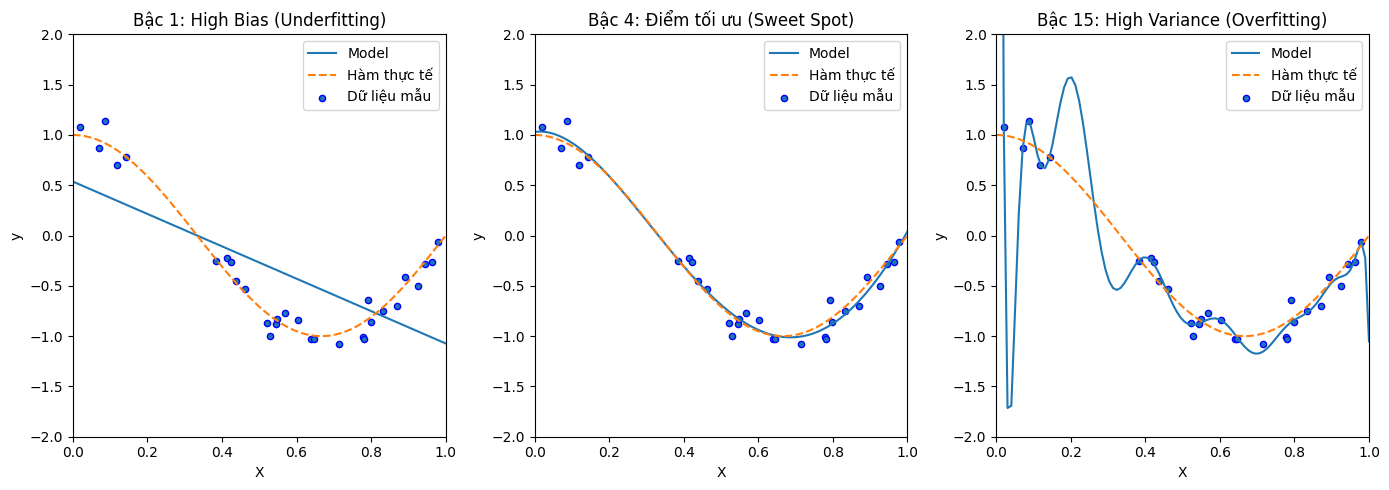

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sinh dữ liệu hàm phi tuyến thực (True Function) + Nhiễu
np.random.seed(0)
def true_function(X):
    return np.cos(1.5 * np.pi * X)

n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.randn(n_samples) * 0.1

# Trực quan hóa 3 trạng thái: Underfitting, Optimal, Overfitting
X_test = np.linspace(0, 1, 100)
plt.figure(figsize=(14, 5))

degrees = [1, 4, 15] # Bậc của đa thức
titles = ['Bậc 1: High Bias (Underfitting)', 
          'Bậc 4: Điểm tối ưu (Sweet Spot)', 
          'Bậc 15: High Variance (Overfitting)']

for i in range(len(degrees)):
    ax = plt.subplot(1, 3, i + 1)
    
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = make_pipeline(polynomial_features, linear_regression)
    pipeline.fit(X[:, np.newaxis], y)
    
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_function(X_test), label="Hàm thực tế", linestyle='--')
    plt.scatter(X, y, edgecolor='b', s=20, label="Dữ liệu mẫu")
    
    plt.xlabel("X")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(titles[i])

plt.tight_layout()
plt.show()

# Phân tích:
# - Đồ thị 1: Đường thẳng không thể nắm bắt đường cong. Bias cao. (Chệch)
# - Đồ thị 3: Đa thức bậc 15 uốn lượn kịch liệt để chạm vào mọi điểm nhiễu. Variance khổng lồ.
# - Đồ thị 2: Cân bằng hoàn hảo. Tổng sai số MSE trên dữ liệu mới sẽ là thấp nhất.

## 4.3. Ridge Regression (L2 Penalty): Sự thỏa hiệp của Phương sai

Khi đối mặt với sự sụp đổ của mô hình OLS do đa cộng tuyến (Multicollinearity) hoặc do số lượng biến quá lớn ($p > n$), nhà thống kê học Arthur Hoerl và Robert Kennard (1970) đã đề xuất một giải pháp đột phá mang tên **Ridge Regression** (Hồi quy Gờ). 

Nguyên lý cốt lõi của Ridge Regression là từ bỏ mục tiêu tìm kiếm một ước lượng không chệch (Unbiased). Thay vào đó, thuật toán chủ động áp đặt một "hình phạt" (Penalty) lên độ lớn của các hệ số hồi quy $\beta$. Hình phạt này ép các hệ số co lại (Shrinkage) về gần 0, từ đó giảm thiểu sự rung lắc (Variance) của mô hình.

### 4.3.1. Hàm mục tiêu của Ridge Regression

Hàm mục tiêu của Ridge không chỉ tối thiểu hóa Tổng bình phương phần dư (RSS) như OLS, mà cộng thêm một thành phần phạt chuẩn L2 (L2 Norm Penalty).

$$J_{Ridge}(\boldsymbol{\beta}) = \text{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2 = (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta}) + \lambda \boldsymbol{\beta}^T \boldsymbol{\beta}$$

**Giải thích chi tiết các ký hiệu toán học:**
- $J_{Ridge}(\boldsymbol{\beta})$: Hàm mất mát (Loss function) của mô hình Ridge mà ta cần tìm cực tiểu.
- $(\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})$: Chính là hàm RSS kinh điển của OLS, đại diện cho độ sai lệch giữa dữ liệu thực tế và giá trị dự báo.
- $\sum_{j=1}^{p} \beta_j^2$ hoặc $\boldsymbol{\beta}^T \boldsymbol{\beta}$: Tổng bình phương của các hệ số hồi quy (không bao gồm hệ số chặn $\beta_0$). Đây là chuẩn L2 bình phương ($||\boldsymbol{\beta}||_2^2$). Nó trừng phạt những mô hình có các hệ số $\beta$ quá lớn.
- $\lambda \ge 0$: Siêu tham số điều chuẩn (Tuning/Regularization parameter). 
  - Khi $\lambda = 0$, hình phạt biến mất, Ridge thoái hóa trở lại thành OLS.
  - Khi $\lambda \to \infty$, hình phạt là tuyệt đối, mọi hệ số $\beta_1, \dots, \beta_p$ đều bị ép về đúng bằng 0 (mô hình chỉ còn lại hệ số chặn $\beta_0$).

---

### 4.3.2. Chứng minh Toán học: Nghiệm đóng (Closed-form Solution) của Ridge

Bởi vì hàm mục tiêu của Ridge là một hàm lồi (Convex function) và khả vi toàn cục, ta có thể tìm nghiệm chính xác bằng cách lấy đạo hàm theo vector $\boldsymbol{\beta}$ và cho bằng $\mathbf{0}$.

Khai triển hàm mục tiêu:
$$J_{Ridge}(\boldsymbol{\beta}) = \mathbf{Y}^T\mathbf{Y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{Y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} + \lambda \boldsymbol{\beta}^T \boldsymbol{\beta}$$

Lấy đạo hàm bậc nhất theo vector $\boldsymbol{\beta}$:
$$\frac{\partial J_{Ridge}}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^T\mathbf{Y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} + 2\lambda \boldsymbol{\beta} = \mathbf{0}$$

Chia cả hai vế cho 2 và nhóm $\boldsymbol{\beta}$ làm nhân tử chung. Chú ý rằng $\lambda \boldsymbol{\beta}$ có thể được viết lại dưới dạng ma trận là $(\lambda \mathbf{I})\boldsymbol{\beta}$ để có thể cộng với ma trận $\mathbf{X}^T\mathbf{X}$:
$$(\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})\boldsymbol{\beta} = \mathbf{X}^T\mathbf{Y}$$

Nhân từ bên trái với ma trận nghịch đảo, ta thu được nghiệm cuối cùng:
$$\hat{\boldsymbol{\beta}}_{ridge} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{Y}$$

**Giải thích ký hiệu bổ sung:**
- $\mathbf{I}$: Ma trận đơn vị (Identity Matrix) có kích thước $(p \times p)$, với các phần tử trên đường chéo chính bằng 1 và các phần tử khác bằng 0.
- $\hat{\boldsymbol{\beta}}_{ridge}$: Vector hệ số ước lượng của Ridge, có tính chất bị chệch (Biased) so với tham số thực của tổng thể, nhưng có phương sai nhỏ hơn rất nhiều so với OLS.

---

### 4.3.3. Giải thích Đại số và Hình học: Tại sao $\lambda \mathbf{I}$ giải cứu đa cộng tuyến?

**Dưới góc độ Đại số tuyến tính (Linear Algebra):**
Như đã phân tích ở Mục 4.1, khi có đa cộng tuyến, ma trận $(\mathbf{X}^T\mathbf{X})$ trở nên gần suy biến. Các giá trị riêng (Eigenvalues) của nó, giả sử là $v_1, v_2, \dots, v_p$, sẽ có những giá trị tiến rất sát về $0$. Nghịch đảo của ma trận chứa các phần tử $1/v_j$, khiến hệ số OLS bùng nổ ra vô cực.

Phép cộng thêm $\lambda \mathbf{I}$ chính là phép toán biến đổi ma trận kỳ diệu nhất. Nó cộng thêm đúng một lượng hằng số $\lambda$ vào đường chéo chính của $(\mathbf{X}^T\mathbf{X})$. Hệ quả là, các giá trị riêng mới của ma trận $(\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})$ sẽ là:
$$(v_1 + \lambda), (v_2 + \lambda), \dots, (v_p + \lambda)$$
Dù $v_j$ có bằng 0 đi chăng nữa, thì $(v_j + \lambda)$ vẫn là một số dương hoàn toàn (vì $\lambda > 0$). Ma trận mới này bị ép buộc trở thành ma trận xác định dương (Positive Definite), do đó nó **chắc chắn có thể nghịch đảo được một cách ổn định**. Sự bùng nổ số học bị triệt tiêu hoàn toàn.

---

## 4.4. Lasso Regression (L1 Penalty) & Sparsity (Tính thưa)

Mặc dù Ridge Regression giải quyết xuất sắc vấn đề đa cộng tuyến, nó có một nhược điểm trong thực hành kinh doanh: Nó thu nhỏ tất cả các hệ số $\beta$ về rất gần 0, nhưng **không bao giờ bằng chính xác 0**. Nếu bạn có 10,000 biến số, mô hình Ridge cuối cùng vẫn sẽ cần 10,000 biến số đó để dự báo. Điều này làm mất đi tính diễn giải (Interpretability).

Năm 1996, Robert Tibshirani công bố thuật toán **Lasso** (Least Absolute Shrinkage and Selection Operator). Cú twist thiên tài của Tibshirani là thay thế hình phạt L2 bằng hình phạt L1.

### 4.4.1. Hàm mục tiêu của Lasso Regression

$$J_{Lasso}(\boldsymbol{\beta}) = \text{RSS} + \lambda \sum_{j=1}^{p} |\beta_j| = (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{Y} - \mathbf{X}\boldsymbol{\beta}) + \lambda ||\boldsymbol{\beta}||_1$$

**Giải thích thành phần khác biệt:**
- $\sum_{j=1}^{p} |\beta_j|$ hoặc $||\boldsymbol{\beta}||_1$: Đây là chuẩn L1 (L1 Norm), tính bằng tổng giá trị tuyệt đối của các hệ số hồi quy. 
- Trái với Ridge (hàm bậc 2 có đạo hàm trơn tru), hàm giá trị tuyệt đối $|x|$ tạo ra một điểm gãy (không có đạo hàm) tại $x = 0$. Chính ranh giới sắc nhọn này đã mang lại cho Lasso một siêu năng lực: **Khả năng tự động loại bỏ biến (Feature Selection)**.

*(Lưu ý: Vì hàm mục tiêu không khả vi tại 0, Lasso không có nghiệm đóng (Closed-form solution) như Ridge. Nó phải được giải bằng các thuật toán lặp tối ưu hóa như Coordinate Descent).* 

---

### 4.4.2. So sánh Hình học: Bí ẩn của Hình Tròn và Hình Thoi

Để hiểu tại sao Lasso ép hệ số về 0 còn Ridge thì không, chúng ta phải chuyển bài toán tối ưu hóa không ràng buộc (Unconstrained optimization) có chứa $\lambda$ thành một bài toán tối ưu hóa có ràng buộc (Constrained optimization) với một giới hạn ngân sách $t$.

Về mặt toán học tương đương, ta cần tìm cực tiểu cho hàm RSS: $\min \text{RSS}(\boldsymbol{\beta})$
- **Với Ridge:** Ràng buộc $\beta_1^2 + \beta_2^2 \le t$. Phương trình này tạo ra một **Vùng giới hạn hình tròn (Tròn trơn).**
- **Với Lasso:** Ràng buộc $|\beta_1| + |\beta_2| \le t$. Phương trình này tạo ra một **Vùng giới hạn hình thoi (Hình vuông xoay có các góc nhọn).**

**Trực giác Hình học (Geometric Interpretation):**
Tưởng tượng trong không gian 2D (chỉ có 2 biến $\beta_1$ và $\beta_2$). Hàm mục tiêu RSS của OLS tạo thành các đường đồng mức hình Elip (như những thung lũng lồng vào nhau), với điểm tâm là nghiệm OLS gốc $(\hat{\beta}_1, \hat{\beta}_2)$.
Để tìm nghiệm của Ridge/Lasso, các đường Elip này sẽ phình to dần ra cho đến khi chúng "chạm" vào Vùng giới hạn ràng buộc (Ngân sách $t$). Điểm tiếp xúc đầu tiên chính là lời giải.

- **Sự kiện tại đường tròn (Ridge):** Vì vùng ràng buộc của Ridge là một đường tròn trơn (không có góc cạnh), hình Elip của RSS có thể tiếp xúc với đường tròn ở bất kỳ điểm nào. Tại điểm tiếp xúc đó, cả $\beta_1$ và $\beta_2$ đều có giá trị khác 0 (chỉ bị thu nhỏ lại).
- **Sự kiện tại góc nhọn (Lasso):** Vùng ràng buộc của Lasso là một hình thoi với 4 đỉnh nhọn nằm CHÍNH XÁC trên các trục tọa độ. Về mặt xác suất hình học, khi một hình Elip phình to ra, khả năng cao nhất là nó sẽ đập vào một trong các "góc nhọn" nhô ra của hình thoi trước tiên. Khi điểm tiếp xúc xảy ra ngay tại góc nhọn nằm trên trục tung, thì tọa độ của nó là $(0, \beta_2)$. Nghĩa là biến $\beta_1$ đã bị ép về đúng bằng 0.

Thuộc tính này tạo ra mô hình **Sparsity (Tính thưa)**, vô cùng quý giá trong Tài chính và Marketing để chọn lọc ra đúng những biến cốt lõi nhất từ hàng ngàn tín hiệu nhiễu.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU ĐA CỘNG TUYẾN MẠNH (p=4 variables)
# ========================================================
np.random.seed(42)
N = 100

# X1 là biến cốt lõi thực sự
X1 = np.random.randn(N)
# X2, X3, X4 là các biến "ăn theo", được copy từ X1 kèm theo chút nhiễu (Đa cộng tuyến hoàn hảo)
X2 = X1 + np.random.normal(0, 0.01, N)
X3 = X1 + np.random.normal(0, 0.05, N)
X4 = np.random.randn(N) # Biến rác hoàn toàn ngẫu nhiên

# Biến phụ thuộc Y chỉ bị tác động thực sự bởi X1
Y = 10 + 5 * X1 + np.random.normal(0, 1, N)

X = pd.DataFrame({'X1_Core': X1, 'X2_Copy1': X2, 'X3_Copy2': X3, 'X4_Noise': X4})

# Chuẩn hóa dữ liệu (BẮT BUỘC trước khi chạy Ridge/Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ========================================================
# BƯỚC 2: HUẤN LUYỆN CÁC MÔ HÌNH (OLS, RIDGE, LASSO)
# ========================================================
alpha_penalty = 1.5 # Mức độ trừng phạt lambda

ols = LinearRegression().fit(X_scaled, Y)
ridge = Ridge(alpha=alpha_penalty).fit(X_scaled, Y)
lasso = Lasso(alpha=alpha_penalty).fit(X_scaled, Y)

# ========================================================
# BƯỚC 3: SO SÁNH HỆ SỐ ĐỂ THẤY SỰ LỰA CHỌN BIẾN (SPARSITY)
# ========================================================
coef_df = pd.DataFrame({
    'Features': X.columns,
    'OLS_Beta': np.round(ols.coef_, 2),
    'Ridge_Beta': np.round(ridge.coef_, 2),
    'Lasso_Beta': np.round(lasso.coef_, 2)
})

print("BẢNG SO SÁNH HỆ SỐ HỒI QUY (COEFFICIENTS):\n")
print(coef_df)
print("\n=> PHÂN TÍCH KẾT QUẢ:")
print("- OLS bị ảo giác do Đa cộng tuyến. Nó chia sức mạnh lung tung cho X1, X2, X3, thậm chí tạo ra các hệ số âm dương triệt tiêu nhau.")
print("- Ridge co cụm các hệ số lại cho an toàn. Nó chia đều sức mạnh cho cả X1, X2, X3. Không có hệ số nào bằng 0.")
print("- Lasso (L1 Penalty) thể hiện sự tàn nhẫn và sắc bén: Nó nhận ra X1, X2, X3 là cùng một thực thể. Nó giữ lại X2, và ÉP TOÀN BỘ X1, X3, X4 về ĐÚNG 0.00. Mô hình trở nên cực kỳ tinh gọn (Sparse).")


BẢNG SO SÁNH HỆ SỐ HỒI QUY (COEFFICIENTS):

   Features  OLS_Beta  Ridge_Beta  Lasso_Beta
0   X1_Core    -12.44        1.62        1.14
1  X2_Copy1     18.43        1.74        1.74
2  X3_Copy2     -1.58        1.03        0.00
3  X4_Noise      0.22        0.20       -0.00

=> PHÂN TÍCH KẾT QUẢ:
- OLS bị ảo giác do Đa cộng tuyến. Nó chia sức mạnh lung tung cho X1, X2, X3, thậm chí tạo ra các hệ số âm dương triệt tiêu nhau.
- Ridge co cụm các hệ số lại cho an toàn. Nó chia đều sức mạnh cho cả X1, X2, X3. Không có hệ số nào bằng 0.
- Lasso (L1 Penalty) thể hiện sự tàn nhẫn và sắc bén: Nó nhận ra X1, X2, X3 là cùng một thực thể. Nó giữ lại X2, và ÉP TOÀN BỘ X1, X3, X4 về ĐÚNG 0.00. Mô hình trở nên cực kỳ tinh gọn (Sparse).


## 4.5. Elastic Net: Sự kết hợp giữa L1 và L2

Mặc dù Lasso (L1) có khả năng chọn biến tuyệt vời bằng cách ép các hệ số về 0, nó bộc lộ hai điểm yếu chí mạng trong thực tiễn:
1. **Giới hạn số lượng biến (Saturation):** Khi số lượng biến $p$ lớn hơn số quan sát $n$ ($p > n$), Lasso chỉ có thể chọn tối đa $n$ biến trước khi bị bão hòa. Nó buộc phải vứt bỏ toàn bộ phần còn lại.
2. **Hành vi chọn ngẫu nhiên với Đa cộng tuyến:** Khi đối mặt với một nhóm các biến có độ tương quan cực kỳ cao (ví dụ: Tỷ giá USD/VND, EUR/VND, JPY/VND), Lasso có xu hướng chỉ chọn ngẫu nhiên **một** biến trong nhóm đó và ép tất cả các biến còn lại về 0. Điều này làm mất đi thông tin hệ thống của cả nhóm.

Năm 2005, Zou và Hastie đề xuất **Elastic Net**, một giải pháp lai tạo (hybrid) thừa hưởng cả "tính thưa" (Sparsity) của Lasso và "hiệu ứng nhóm" (Grouping effect) của Ridge.

### 4.5.1. Phương trình Toán học của Elastic Net

Hàm mục tiêu của Elastic Net là sự thỏa hiệp tuyến tính giữa hai hình phạt L1 và L2:

$$J_{Elastic}(\boldsymbol{\beta}) = \text{RSS} + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2$$

Trong các thư viện Lập trình (như Scikit-learn), hàm này thường được viết lại dưới dạng kiểm soát bằng tổng mức độ phạt $\alpha$ và tỷ lệ pha trộn $\rho$ (L1_ratio):

$$J_{Elastic}(\boldsymbol{\beta}) = \frac{1}{2N} \text{RSS} + \alpha \rho ||\boldsymbol{\beta}||_1 + \frac{\alpha (1 - \rho)}{2} ||\boldsymbol{\beta}||_2^2$$

**Giải thích chi tiết:**
- $\alpha$ (tương đương $\lambda$ tổng): Quyết định tổng cường độ trừng phạt lên mô hình.
- $\rho \in [0, 1]$ (L1_ratio): Tỷ lệ chi phối của Lasso. 
  - Nếu $\rho = 1$: Mô hình hoàn toàn là Lasso.
  - Nếu $\rho = 0$: Mô hình hoàn toàn là Ridge.
  - Nếu $\rho = 0.5$: Mô hình chia đều 50% tính chất L1 và 50% tính chất L2.

### 4.5.2. Khi nào nên dùng Elastic Net?

**Trực giác Hình học:** Hàm phạt của Elastic Net tạo ra một vùng giới hạn là hình sự giao thoa giữa Hình tròn (Ridge) và Hình thoi (Lasso). Nó có các đỉnh nhọn (để tạo ra Sparsity - ép biến về 0), nhưng các cạnh của nó lại có độ cong lồi (Strictly convex) giống hình tròn.

**Đặc tính "Grouping Effect":** Nhờ độ cong của hình phạt L2, nếu có một nhóm biến tương quan mạnh, thay vì chỉ chọn một biến duy nhất như Lasso, Elastic Net sẽ có xu hướng **chọn toàn bộ nhóm đó** hoặc **loại bỏ toàn bộ nhóm đó**, và chia đều (shrink) các hệ số cho các biến trong nhóm được chọn. 

=> **Khuyến nghị thực tiễn:** Luôn sử dụng Elastic Net khi bạn làm việc với dữ liệu vĩ mô hoặc tài chính (nơi Đa cộng tuyến là bản chất của thị trường), đặc biệt trong kịch bản dữ liệu gen học (Genomics) hoặc text mining nơi $p \gg n$.

---

## 4.6. Thực hành Python và Thẩm định chéo (Cross-Validation)

Làm sao để biết $\alpha$ bằng $0.1, 1.0$ hay $10.0$ là tốt nhất? Chúng ta không thể thử nghiệm $\alpha$ trên tập dữ liệu Train (vì nếu vậy mô hình sẽ luôn chọn $\alpha = 0$ để tối thiểu hóa RSS). Cũng không thể dùng tập Test (vì như vậy là gian lận, rò rỉ dữ liệu). Giải pháp là **K-Fold Cross Validation**.

### 4.6.1. Cơ chế của K-Fold Cross Validation
1. Chia tập huấn luyện (Train set) thành $K$ phần bằng nhau (Folds), ví dụ $K=5$.
2. Với một giá trị $\alpha$ cụ thể, ta huấn luyện mô hình $K$ lần. Mỗi lần, ta lấy 1 Fold làm tập Kiểm định (Validation set) và $K-1$ Folds còn lại làm tập Huấn luyện (Train set).
3. Tính trung bình sai số dự báo (Mean Squared Error - MSE) của cả $K$ lần chạy.
4. Lặp lại bước 2-3 cho một dải các giá trị $\alpha$ (Grid Search). Chọn $\alpha$ mang lại MSE trung bình nhỏ nhất.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU TÀI CHÍNH GIẢ LẬP (CÓ ĐA CỘNG TUYẾN)
# ========================================================
np.random.seed(42)
N = 200
p = 10 # 10 biến độc lập (VD: 10 chỉ số tài chính)

# Tạo một biến tiềm ẩn (Latent factor - ví dụ: Sức khỏe chung của nền kinh tế)
latent_factor = np.random.randn(N)

# Tạo 10 biến X có độ tương quan cao với nhau thông qua latent_factor
X = np.zeros((N, p))
for i in range(p):
    X[:, i] = latent_factor + np.random.normal(0, 0.5, N) 

# Chỉ có X_0, X_1, X_2 là thực sự tạo ra Y (Target). X_3 đến X_9 là nhiễu.
Y = 10 + 5*X[:, 0] + 3*X[:, 1] + 2*X[:, 2] + np.random.normal(0, 2, N)

# Chia tập dữ liệu
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# CHUẨN HÓA DỮ LIỆU BẮT BUỘC TRƯỚC KHI DÙNG PENALTY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================================
# BƯỚC 2: TÌM ALPHA TỐI ƯU BẰNG K-FOLD CROSS VALIDATION
# ========================================================
# Tạo một lưới (grid) các giá trị alpha chạy từ 0.01 đến 100 theo thang logarit
alphas_grid = np.logspace(-2, 2, 100)

# RidgeCV: Mặc định dùng Leave-One-Out (hoặc K-Fold). Ta set cv=5 (5-Fold CV)
ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(X_train_scaled, Y_train)

# LassoCV: Mặc định dùng 5-Fold CV
lasso_cv = LassoCV(alphas=alphas_grid, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, Y_train)

print("========== KẾT QUẢ CROSS-VALIDATION ==========")
print(f"Ridge - Alpha tối ưu: {ridge_cv.alpha_:.4f}")
print(f"Lasso - Alpha tối ưu: {lasso_cv.alpha_:.4f}\n")


========== KẾT QUẢ CROSS-VALIDATION ==========
Ridge - Alpha tối ưu: 1.5199
Lasso - Alpha tối ưu: 0.0643



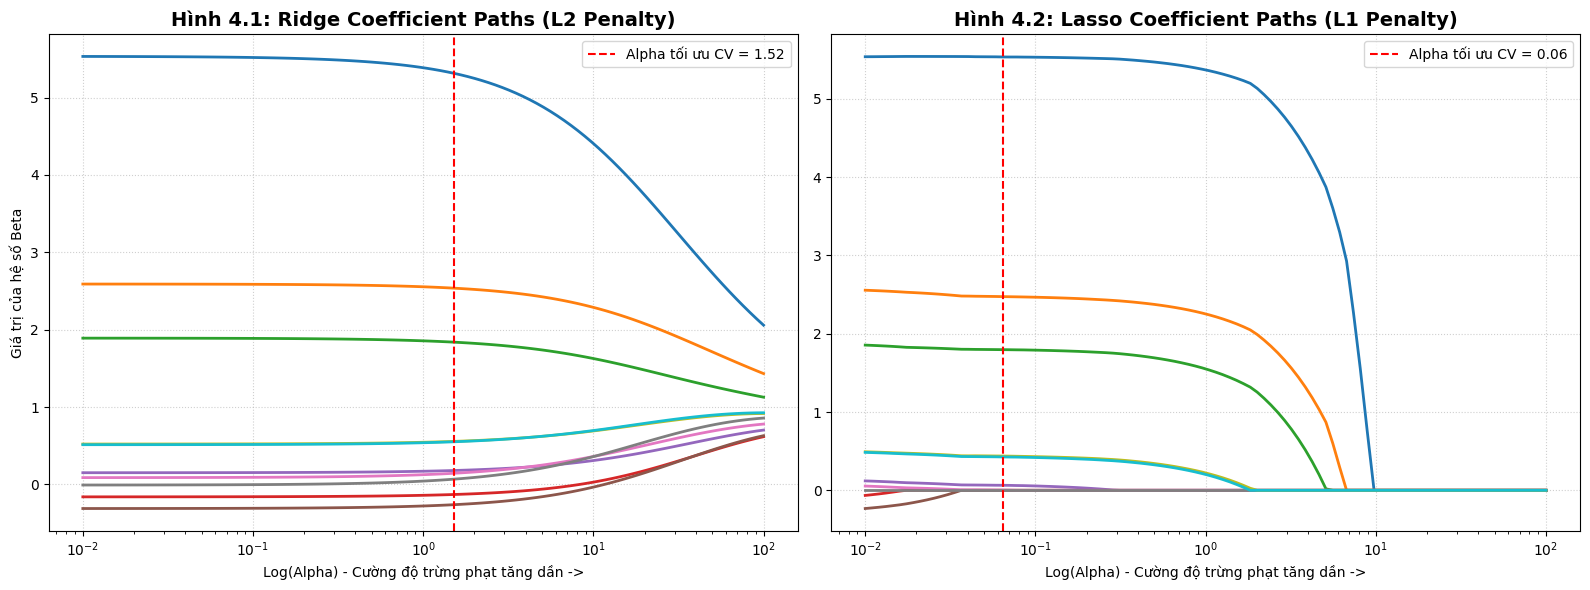

In [13]:
# ========================================================
# BƯỚC 3: VẼ BIỂU ĐỒ "HỆ SỐ CO RÚT" (COEFFICIENT PATHS)
# ========================================================
# Tính toán hệ số cho từng alpha trong grid
ridge_coefs = []
lasso_coefs = []

for a in alphas_grid:
    # Ridge path
    r = Ridge(alpha=a)
    r.fit(X_train_scaled, Y_train)
    ridge_coefs.append(r.coef_)
    
    # Lasso path
    l = Lasso(alpha=a)
    l.fit(X_train_scaled, Y_train)
    lasso_coefs.append(l.coef_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Ridge Path
axes[0].plot(alphas_grid, ridge_coefs, linewidth=2)
axes[0].set_xscale('log')
axes[0].axvline(ridge_cv.alpha_, color='red', linestyle='--', label=f'Alpha tối ưu CV = {ridge_cv.alpha_:.2f}')
axes[0].set_title('Hình 4.1: Ridge Coefficient Paths (L2 Penalty)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log(Alpha) - Cường độ trừng phạt tăng dần ->')
axes[0].set_ylabel('Giá trị của hệ số Beta')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Lasso Path
axes[1].plot(alphas_grid, lasso_coefs, linewidth=2)
axes[1].set_xscale('log')
axes[1].axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Alpha tối ưu CV = {lasso_cv.alpha_:.2f}')
axes[1].set_title('Hình 4.2: Lasso Coefficient Paths (L1 Penalty)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Alpha) - Cường độ trừng phạt tăng dần ->')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Phân tích biểu đồ Coefficient Paths (Sự co rút của Hệ số)

Biểu đồ **Coefficient Paths** là công cụ trực quan mạnh mẽ nhất để hiểu cách các thuật toán Điều chuẩn hoạt động khi chúng ta tăng dần "đòn roi" (Tham số $\alpha$). Trục hoành là thang logarit của $\alpha$ (càng sang phải, hình phạt càng nặng). Trục tung là giá trị của 10 hệ số $\beta$.

**1. Phân tích Hình 4.1 (Ridge Paths - L2 Penalty):**
- Ở góc tận cùng bên trái ($\alpha \to 0$), các hệ số phân tán rải rác. Đây chính là trạng thái hỗn loạn của OLS do Đa cộng tuyến gây ra (mặc dù chỉ có 3 biến gốc là có thật, OLS lại gán trọng số ảo cho cả 10 biến).
- Khi $\alpha$ tăng dần, các đường cong **từ từ chụm lại với nhau** và tiệm cận về 0 một cách mượt mà (Asymptotic shrinkage). 
- Không có bất kỳ đường nào bị ép chạm vạch 0 hoàn toàn. Ridge giữ lại tất cả 10 biến. Nó tin rằng việc chia đều rủi ro (phương sai) cho tất cả các biến là chiến lược tốt nhất.

**2. Phân tích Hình 4.2 (Lasso Paths - L1 Penalty):**
- Trái ngược với sự mềm mỏng của Ridge, Lasso hành xử như một máy chém. Khi $\alpha$ tăng lên, các đường hệ số đập thẳng vào trục 0 và **dừng lại hẳn ở đó**.
- Hãy nhìn vào đường nét đứt màu đỏ (Alpha tối ưu tìm được qua Cross-Validation). Tại điểm cắt này, phần lớn các đường (đại diện cho 7 biến nhiễu $X_3$ đến $X_9$) đã bị đè bẹp hoàn toàn xuống 0.
- Chỉ còn lại 3 đường sống sót ở trên trục hoành. Thuật toán Lasso đã thành công xuất sắc trong việc thực hiện **Chọn biến tự động (Feature Selection)**, lôi ra đúng 3 tín hiệu gốc khỏi mớ dữ liệu hỗn mang đa cộng tuyến.